# 2CSSIQ Lab01. Logistic Regression

<p style='text-align: right;font-style: italic;'>Designed by: Dr. Abdelkrime Aries</p>

In this lab, we will learn all about logistic regression:
- Linear regression
- Binary logistic regression
- Multi-class logistic regression
- Multi-label logistic regression

**Team:**
- **Member 01**: Salsabila CHATTAH
- **Member 02**: Ikram BADAOUI
- **Group**: SIQ1

In [2]:
import sys, timeit
from typing          import Tuple, List, Type
from collections.abc import Callable

sys.version

'3.13.7 (main, Aug 20 2025, 22:17:40) [GCC 14.3.0]'

In [3]:
import numpy             as np
import pandas            as pd 
import matplotlib.pyplot as plt 
import matplotlib
%matplotlib inline

np.__version__, pd.__version__, matplotlib.__version__

('2.3.5', '2.3.3', '3.10.8')

In [4]:
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.linear_model    import SGDClassifier
from sklearn.multiclass      import OneVsRestClassifier
from sklearn.multiclass      import OneVsOneClassifier
from sklearn.metrics         import accuracy_score
from sklearn.metrics         import classification_report
from sklearn.metrics         import log_loss

sklearn.__version__

'1.8.0'

In [5]:
# This code is used to filter warnings concerning convergence
# In general, when the maximum number of iterations is not suffisant to converge
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

## I. Algorithms implementation

In this section, we will try to implement all forms of linear/logistic regression. In fact, those forms are similar and use almost the same algorithms. For example, multi-label LR is actually binary regression with multiple outputs. 


**>> Try to use "numpy" which will save a lot of time and effort**

### I.1. Prediction functions

We want to implement all prediction functions used for linear regression, binary logistic regression and Maximum entropy (Logistic regression with softmax).

#### I.1.1. Linear combination

Given an input:
- $X[M, N]$ a matrix of $M$ samples and $N$ features

and some parameters ($theta_0$ is already embedded as the first parameter):
- $\theta[N]$: in case of binary classification 
- $\theta[N, L]$: in case of multi-class classification. $L$ is the number of classes/labels.

calculate the output: 
- $Z[M]$: each sample has one output (binary)
- $Z[M, L]$: each sample has $L$ outputs (multiple)

each class/label $c$ (in case of binary classification, there is only one label) has an output:
$$Z_c = \sum\limits_{j=0}^{N} \theta_{(c, j)} X_j | X_0 = 1 $$

A more general form: 
$$Z = zfn(X, \theta) = X \cdot \theta$$


In [6]:
def zfn(X: np.ndarray, Theta: np.ndarray) -> np.ndarray: 
    return X @ Theta

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# (array([3.7, 1.6, 7.2]),
#  array([[0.2 , 0.5 , 0.1 ],
#         [0.8 , 0.95, 0.65],
#         [0.1 , 0.25, 0.05],
#         [0.45, 0.6 , 0.35]]))
#---------------------------------------------------------------------

X_t     = np.array([[1., 50. ], 
                    [1., 20. ], 
                    [1., 100.]])
Theta_t = np.array([0.2, 0.07])

X_tL = np.array([[0., 1.], 
                 [1., 1.5], 
                 [0., 0.5], 
                 [0.5, 1.]]) # 4 samples, 2 features
Theta_tL = np.array([[0.5, 0.2, 0.5],
                     [0.2, 0.5, 0.1]]) # 2 features, 3 classes
# binary, multiple
zfn(X_t, Theta_t), zfn(X_tL, Theta_tL)

(array([3.7, 1.6, 7.2]),
 array([[0.2 , 0.5 , 0.1 ],
        [0.8 , 0.95, 0.65],
        [0.1 , 0.25, 0.05],
        [0.45, 0.6 , 0.35]]))

#### I.1.2. Logistic function

Given the linear combination:
- $Z[M]$: each sample has one output (binary)
- $Z[M, L]$: each sample has $L$ outputs (multiple)

We generate prediction probabilities:
- $H[M]$: each sample has one output (binary)
- $H[M, L]$: each sample has $L$ outputs (multiple)

Using the logistic function:
$$H = \sigma(Z) = \frac{1}{1+e^{-Z}}$$

**>> Using numpy arrays, this function works for vectors and matrices**

In [7]:
# TODO: Logistic function
def sgfn(Z: 'np.ndarray[M, L]') -> 'np.ndarray[M, L]': 
    return  1 / (1 + np.exp(-Z))

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# (array([0.97587298, 0.83201839, 0.99925397]),
#  array([[0.549834  , 0.62245933, 0.52497919],
#         [0.68997448, 0.72111518, 0.65701046],
#         [0.52497919, 0.5621765 , 0.5124974 ],
#         [0.61063923, 0.64565631, 0.58661758]]))
#---------------------------------------------------------------------

Z_t = np.array([3.7, 1.6, 7.2])
Z_tL = np.array([[0.2 , 0.5 , 0.1 ],
                 [0.8 , 0.95, 0.65],
                 [0.1 , 0.25, 0.05],
                 [0.45, 0.6 , 0.35]])

# binary, multiple
sgfn(Z_t), sgfn(Z_tL)

(array([0.97587298, 0.83201839, 0.99925397]),
 array([[0.549834  , 0.62245933, 0.52497919],
        [0.68997448, 0.72111518, 0.65701046],
        [0.52497919, 0.5621765 , 0.5124974 ],
        [0.61063923, 0.64565631, 0.58661758]]))

#### I.1.3. Softmax function

Given the linear combination:
- $Z[M, L]$: each sample has $L$ outputs (multiple)

We generate predictions:
- $H[M, L]$: each sample has $L$ outputs (multiple)

Using the softmax function:
$$H = softmax(Z)=\frac{e^Z}{\sum\limits_{k=1}^{L} e^{Z_k}}$$

Basically:
- Calculate $H' = e^Z$
- Then divide $H'$ by the vector $H'$ summed over colums
- numpy automatically transforms a vector $V[M, 1]$ into $V[M]$. So, you have to force a vertical vector using **reshape(-1, 1)**.
- The sum of probabilities in each row must equal 1

In [8]:
# TODO: Softmax function
def softmaxfn(Z: np.ndarray) -> np.ndarray:
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# array([[0.09003057, 0.24472847, 0.66524096],
#        [0.36029662, 0.24151404, 0.39818934],
#        [0.33333333, 0.33333333, 0.33333333],
#        [0.46396343, 0.25462853, 0.28140804]])
#---------------------------------------------------------------------

Z_tL = np.array([[1. , 2. , 3. ],
                 [0.5, 0.1, 0.6],
                 [0.2, 0.2, 0.2],
                 [0.7, 0.1, 0.2]])
softmaxfn(Z_tL)

array([[0.09003057, 0.24472847, 0.66524096],
       [0.36029662, 0.24151404, 0.39818934],
       [0.33333333, 0.33333333, 0.33333333],
       [0.46396343, 0.25462853, 0.28140804]])

### I.2. Cost functions

We want to implement these cost functions:
- Mean Square Error (MSE): for linear regression
- Binary Cross Entropy (BCE): for binary logistic regression and multi-label logistic regression
- Cross Entropy (CE): for maximum entropy (MaxEnt) algorithm (multi-class logistic regression)


#### I.2.1. Mean Square Error (MSE)

Given the estimated outputs $H[M]$, calculate the error based on the real outputs $Y[M]$.

$$J = MSE(Y, H) = \frac{1}{2M} \sum\limits_{i=1}^{M} (Y - H)^2$$

**>> This is used for linear regression which is applicable only on one output per sample**

In [ ]:
# TODO: MSE cost function
def MSEfn(H: 'np.ndarray[M]',
          Y: 'np.ndarray[M]') -> float:
    M = len(Y)
    return np.sum((Y - H)**2) / (2 * M)

#=====================================================================
# UNIT TEST
#=====================================================================
# Result:
# 4.923333333333335
#---------------------------------------------------------------------

H_t = np.array([3.7, 1.6, 7.2])
Y_t = np.array([1., 2., 2.5])
# print(MSEfn(H_t, Y_t))
MSEfn(H_t, Y_t)

np.float64(4.923333333333335)

#### I.2.2. Binary Cross Entropy (BCE)

Given the output probabilities:
- $H[M]$: each sample has one output (binary)
- $H[M, L]$: each sample has $L$ outputs (multi-label)

and the real classes:
- $Y[M]$: each sample has one output (binary)
- $Y[M, L]$: each sample has $L$ outputs (multi-label)

The BCE loss for one sample is:
$$BCE(Y^{(i)}, H^{(i)})
= \begin{cases}
- \log(H^{(i)}) & \text{ si } Y^{(i)} = 1\\ 
- \log(1 - H^{(i)})  & \text{ si } Y^{(i)} = 0
\end{cases}
$$
Since $Y^{(i)} \in \{0, 1\}$, then: 

$$ BCE(Y^{(i)}, H^{(i)}) = - Y^{(i)} \log(H^{(i)}) - (1- Y^{(i)}) \log(1 - H^{(i)}) $$

Then, the loss function will be:
$$J = BCE(Y, H) = \frac{-1}{M} \sum\limits_{i=1}^{M} [Y^{(i)} \log(H^{(i)}) + (1- Y^{(i)}) \log(1 - H^{(i)})]$$

**>> practically, a little value epsilon is added into the log to avoid log(0)**

In [ ]:
# TODO: BCE loss function
def BCEfn(H  : 'np.ndarray[M,L]',
          Y  : 'np.ndarray[M,L]',  
          eps: float = 1e-8   ) -> float: 
    M = Y.shape[0]
    return -np.mean(Y * np.log(H + eps) + (1 - Y) * np.log(1 - H + eps))

#=====================================================================
# UNIT TEST
#=====================================================================
# Result:
# (0.4243218919376292, 0.42432187634239105, 2.1008877306759546)
#---------------------------------------------------------------------

Y_t = np.array([1., 0., 1.])
H_t = np.array([0.7, 0.2, 0.5 ])

Y_tL = np.array([[1, 0, 1],
                 [1, 1, 0],
                 [1, 1, 1],
                 [0, 0, 1]]) # multilabel
H_tL = np.array([[0.5       , 0.5       , 0.5       ],
                 [0.3, 0.5, 0.7],
                 [1.  , 0.8, 0.5       ],
                 [0., 0.5, 0.]])
# print(BCEfn(H_t, Y_t, eps=0), BCEfn(H_t, Y_t),BCEfn(H_tL, Y_tL))
BCEfn(H_t, Y_t, eps=0), BCEfn(H_t, Y_t), BCEfn(H_tL, Y_tL)

0.4243218919376292 0.42432187634239105 2.1008877306759546


(np.float64(0.4243218919376292),
 np.float64(0.42432187634239105),
 np.float64(2.1008877306759546))

#### I.2.3. Cross Entropy (CE)

Given the output probabilities:
- $H[M, L]$: each sample has $L$ outputs (multi-class)

and the real classes:
- $Y[M, L]$: each sample has $L$ outputs (multi-class)

$$J = CE(H, Y) = \frac{-1}{M} \sum\limits_{i=1}^{M} \sum\limits_{c=1}^{L} Y^{(i)}_c \log(H^{(i)}_c)$$

**>> HINT: sum over classes (column), mean over samples**

In [ ]:
# TODO: CE loss function
def CEfn(H: np.ndarray, 
         Y: np.ndarray,
         eps: float = 1e-8 ) -> np.ndarray:
    M = Y.shape[0]
    return -np.sum(Y * np.log(H + eps)) / M

#=====================================================================
# UNIT TEST
#=====================================================================
# Result:
# 1.1913194196637922
#---------------------------------------------------------------------

Y_tL = np.array([[1,0,0], 
                 [0,1,0], 
                 [0,0,1], 
                 [1,0,0]])
H_tL = np.array([[0.33333333, 0.33333333, 0.33333333],
                 [0.36029662, 0.24151404, 0.39818934],
                 [0.34200877, 0.37797814, 0.28001309],
                 [0.37797814, 0.28001309, 0.34200877]])

CEfn(H_tL, Y_tL)
# print(CEfn(H_tL, Y_tL))

1.1913194196637922


### I.3. Gradients

We want to implement these cost functions' gradients:
- dMSE: for linear regression
- dBCE: for binary logistic regression (the same as dMSE) and multi-label logistic regression (a little different)
- dCE: for maximum entropy (MaxEnt) algorithm (multi-class logistic regression)

**>> Good news: gradients function is the same**


Given the input:
- $X[M, N]$ a matrix of $M$ samples and $N$ features

the real output values:
- $Y[M]$: each sample has one output
- $Y[M, L]$: each sample has $L$ outputs

and the estimated output:
- $H[M]$: each sample has one estimated output
- $H[M, L]$: each sample has $L$ estimated outputs

calculate the gradients: 
- $\frac{\partial J}{\partial \theta}[N]$: each feature has one gradient
- $\frac{\partial J}{\partial \theta}[N, L]$: each feature has $L$ gradients

The gradients are calculated as (matrix form):
$$\frac{\partial J}{\partial \theta} = \frac{1}{M} (X^T \cdot (H - Y))$$

---
A BORING CALCULATION (MSE)

$$\frac{\partial MSE}{\partial \theta_j} 
= \frac{\partial }{\partial \theta_j} \frac{1}{2M} \sum\limits_{i=1}^{M} (Y^{(i)} - H^{(i)})^2 
= \frac{1}{2M} \sum\limits_{i=1}^{M} [\frac{\partial }{\partial \theta_j} (Y^{(i)} - H^{(i)})^2]
= \frac{1}{2M} \sum\limits_{i=1}^{M} [-2 (Y^{(i)} - H^{(i)}) \frac{\partial }{\partial \theta_j} H^{(i)}]
$$

$$\frac{\partial MSE}{\partial \theta_j}
= \frac{1}{M} \sum\limits_{i=1}^{M} [(H^{(i)} - Y^{(i)}) \frac{\partial }{\partial \theta_j} \sum\limits_{k=0}^{N} \theta_k X_k^{(i)}]
= \frac{1}{M} \sum\limits_{i=1}^{M} [(H^{(i)} - Y^{(i)}) \frac{\partial }{\partial \theta_j} \theta_j X_j^{(i)}]
$$
$$\frac{\partial MSE}{\partial \theta_j} = \frac{1}{M} \sum\limits_{i=1}^{M} (H^{(i)} - Y^{(i)}) X_j^{(i)}$$

---
A BORING CALCULATION (BCE)

$$\frac{\partial BCE}{\partial \theta_j} 
= \frac{-1}{M} \sum\limits_{i=1}^{M} \frac{\partial}{\partial \theta_j} [Y^{(i)} \log(H^{(i)}) + (1- Y^{(i)}) \log(1 - H^{(i)})]
$$

$$\frac{\partial BCE}{\partial \theta_j} 
= \frac{-1}{M} \sum\limits_{i=1}^{M} [ Y^{(i)} \frac{\partial}{\partial \theta_j} \log(H^{(i)}) + (1- Y^{(i)}) \frac{\partial}{\partial \theta_j}\log(1 - H^{(i)})]
$$

$$\frac{\partial BCE}{\partial \theta_j} 
= \frac{-1}{M} \sum\limits_{i=1}^{M} [ Y^{(i)} \frac{1}{H^{(i)}} \frac{\partial}{\partial \theta_j} H^{(i)} + (1- Y^{(i)}) \frac{-1}{1-H^{(i)}} \frac{\partial}{\partial \theta_j} H^{(i)})]
= \frac{-1}{M} \sum\limits_{i=1}^{M} \frac{Y^{(i)}-H^{(i)}}{H^{(i)}(1-H^{(i)})} \frac{\partial}{\partial \theta_j} H^{(i)}
$$

$$\frac{\partial H^{(i)}}{\partial \theta_j} 
= \frac{\partial \sigma(Z^{(i)})}{\partial Z^{(i)}} \frac{\partial Z^{(i)}}{\partial \theta_j} 
= [\sigma(Z^{(i)}) (1-\sigma(Z^{(i)}))]\frac{\partial}{\partial \theta_j} \sum\limits_{k=0}^{N} \theta_k X_k^{(i)}  
= H^{(i)} (1-H^{(i)})  X_j^{(i)}
$$

$$\frac{\partial BCE}{\partial \theta_j} 
= \frac{-1}{M} \sum\limits_{i=1}^{M} \frac{Y^{(i)}-H^{(i)}}{H^{(i)}(1-H^{(i)})} [H^{(i)} (1-H^{(i)}) X_j^{(i)}]
$$

$$\frac{\partial BCE}{\partial \theta_j} = \frac{1}{M} \sum\limits_{i=1}^{M} (H^{(i)} - Y^{(i)}) X_j^{(i)}$$


In [12]:
# TODO: Gradients
def dJfn(X: np.ndarray, H: np.ndarray, Y: np.ndarray) -> np.ndarray:
    M = Y.shape[0]
    dH = H - Y
    dTheta = X.T @ dH / M
    return dTheta

#=====================================================================
# UNIT TEST
#=====================================================================
# (array([ -0.13333333, -30. ]), 
#  array([[-0.06543131, -0.11961822, 0.18504953], 
#              [-0.07000327, 0.16449781, -0.09449454]]))
#---------------------------------------------------------------------

X_t = np.array([[1., 100.], 
                [1., 200.], 
                [1., 300.]])
H_t = np.array([1. , 1.7, 2.4])
Y_t = np.array([1., 2., 2.5])

X_tL = np.array([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])
H_tL = np.array([[0.33333333, 0.33333333, 0.33333333],
                 [0.36029662, 0.24151404, 0.39818934],
                 [0.34200877, 0.37797814, 0.28001309],
                 [0.37797814, 0.28001309, 0.34200877]])
Y_tL = np.array([[1,0,0], [0,1,0], [0,0,1], [1,0,0]])


dJfn(X_t, H_t, Y_t), dJfn(X_tL, H_tL, Y_tL)

(array([ -0.13333333, -30.        ]),
 array([[-0.06543131, -0.11961822,  0.18504953],
        [-0.07000327,  0.16449781, -0.09449454]]))

### I.4. Final product

**>> Nothing to code here**

This section is to show how all the previous algorithms are merged into one usefull program. 
So, we will use all the previously implemented functions, add some others and implement a class which is easy to use.

#### I.4.1. Gradient descent 

This is the simplest version of gradient descent. It iterates until it reaches the maximum iterations.
It takes estimation function, cost function and gradient function as arguments so we can used it for different problems (linear regression, binary logistic regression, etc.). Also known as polymorphism.

In [13]:
# Gradient descent. By default, it is linear regression
def GDfn (X    : 'np.ndarray[M, N]', # Input M samples, N features (obligatory)
          Y    : 'np.ndarray[M, L]', # Output M samples, L classes (obligatory)
          Theta: 'np.ndarray[N, L]', # Parameters (obligatory)
          IT   : int      = 100    , # Maximum number of iterations
          alpha: float    = 0.01   , # Learning rate
          H_fn : Callable = zfn    , # Estimation function
          J_fn : Callable = MSEfn  , # Cost function
          dJ_fn: Callable = dJfn     # Gradient function
         ) -> Tuple[List[np.ndarray], List[float]]: 
     
    costs  = []           # costs history
    Theta  = Theta.copy() # make a copy of the original parameters
    
    for it in range(IT):
        H  = H_fn (X, Theta) # estimation
        J  = J_fn (H, Y)     # cost
        dJ = dJ_fn(X, H, Y)  # gradients
        
        costs.append(J) # add cost into history
        Theta = Theta - alpha * dJ # update parameters
         
    return Theta, costs

#=====================================================================
# UNIT TEST
#=====================================================================
# Result:
# (array([0.86298175, 0.58991304, 0.96329937]),
#  [6.3375,
#   5.32767996484375,
#   4.48068435059748,
#   3.7702582684901684,
#   3.174380343989813])
#---------------------------------------------------------------------

X_t = np.array([
    [1, 1, 0.2],
    [1, 2, 0.1],
    [1, 3, 0.4],
    [1, 4, 0.3]
])
Theta_t = np.array([1., 1., 1.])
Y_t = np.array([1, 0, 1, 0])

Theta_new, J_hist = GDfn(X_t, Y_t, Theta_t, IT=5)

Theta_new, J_hist

(array([0.86298175, 0.58991304, 0.96329937]),
 [np.float64(6.3375),
  np.float64(5.32767996484375),
  np.float64(4.48068435059748),
  np.float64(3.7702582684901684),
  np.float64(3.174380343989813)])

#### I.4.2. Data preparation functions 

The function **norm** normalizes the input $X' = \frac{X-\mu}{\sigma}$:
- in case of training data $X_{train}$, the mean and standard deviation are calculated on this data
- in case of test data $X_{test}$, the mean and standard deviation must be those calculated over $X_{train}$ (passed as arguments)

The function **prepare** returns a prepared data:
- if norm=True: data will be normalized; otherwise it will be the same
- if bias=True: a column of 1s will be added into $X$ (it is like adding $\theta_0$)

In [14]:
# normalize X based on the 
def normfn(X, mean=None, std=None): 
    if (mean is None) or (std is None): 
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0)
    X_norm = np.where(std==0, X, (X - mean)/std)
    return X_norm, mean, std

def preparefn(X, norm=True, bias=True, mean=None, std=None): 
    X_pre = X.copy()
    if norm: 
        X_pre, mean, std = normfn(X_pre, mean=mean, std=std)
    if bias:
        X_pre = np.append(np.ones((X_pre.shape[0],1)), X_pre ,axis=1)
    return X_pre, mean, std

#=====================================================================
# UNIT TEST
#=====================================================================
# Result:
# ((array([[ 1.        , -1.22474487, -0.26726124],
#          [ 1.        ,  0.        , -1.06904497],
#          [ 1.        ,  1.22474487,  1.33630621]]),
#   array([2.        , 0.23333333]),
#   array([0.81649658, 0.12472191])),
#  (array([[-0.25,  1.  ],
#          [ 0.25,  0.  ],
#          [ 0.75,  3.  ]]),
#   array([1.5, 0.1]),
#   array([2. , 0.1])))
#---------------------------------------------------------------------

X_t = np.array([[1, 0.2],
                [2, 0.1],
                [3, 0.4]])

preparefn(X_t), preparefn(X_t, bias=False, mean=np.array([1.5, 0.1]), std=np.array([2, 0.1]))

((array([[ 1.        , -1.22474487, -0.26726124],
         [ 1.        ,  0.        , -1.06904497],
         [ 1.        ,  1.22474487,  1.33630621]]),
  array([2.        , 0.23333333]),
  array([0.81649658, 0.12472191])),
 (array([[-0.25,  1.  ],
         [ 0.25,  0.  ],
         [ 0.75,  3.  ]]),
  array([1.5, 0.1]),
  array([2. , 0.1])))

#### I.4.3.  Missing functions 

These are functions which must be implemented before 

In [15]:
def vote(H: np.ndarray) -> np.ndarray:
    res = np.zeros(H.shape)
    res[range(len(H)), H.argmax(axis=1)] = 1
    return res


#### I.4.4.  Regression class 

In [16]:
class Regression(object):
    
    def __init__(self, norm=True, bias=True, type='linear'): 
        self.norm  = norm
        self.bias  = bias
        
        # by default linear regression
        self.Hfn : Callable = zfn   # Estimation function
        self.Yfn : Callable = zfn   # Prediction function
        self.Jfn : Callable = MSEfn # Cost function
        self.dJfn: Callable = dJfn  # Gradient function
            
        if type in ['binary', 'multilabel']:
            self.Hfn = lambda X, Theta : sgfn(zfn(X, Theta))
            self.Yfn = lambda X, Theta : (self.Hfn(X, Theta) >= 0.5).astype(int)
            self.Jfn = BCEfn
        elif type == 'multiclass':
            self.Hfn = lambda X, Theta : softmaxfn(zfn(X, Theta))
            self.Yfn = lambda X, Theta : vote(self.Hfn(X, Theta))
            self.Jfn = CEfn
            
    
    def fit(self, X, Y, max_iter=100, alpha=.01) -> List[float]: 
        X_pre, self.mean, self.std = preparefn(X, norm=self.norm, bias=self.bias)
        if len(Y.shape) > 1:
            Theta = np.zeros((X_pre.shape[1], Y.shape[1]))
        else:
            Theta = np.zeros(X_pre.shape[1])
        self.Theta, costs = GDfn(X_pre, Y, Theta, IT=max_iter, alpha=alpha)
        return costs
        
        
    # Predictions
    # if prob=True return probbilities
    # else return labels
    def predict(self, X, prob=True):
        X_pre, _, _ = preparefn(X, norm=self.norm, bias=self.bias, mean=self.mean, std=self.std)
        if prob:
            return self.Hfn(X_pre, self.Theta)
        return self.Yfn(X_pre, self.Theta)


#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# array([[1., 0., 0.],
#        [0., 1., 0.],
#        [0., 1., 0.],
#        [0., 0., 1.]])
#---------------------------------------------------------------------
X_tn = np.array([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])
Y_tn = np.array([[1,0,0], [0,1,0], [0,0,1], [1,0,0]])

X_testn = np.array([[2., 2.], [1., 0.], [1., -1.], [2., 5.]])

maxent = Regression(type='multiclass')
_ = maxent.fit(X_tn, Y_tn)
maxent.predict(X_testn, prob=False)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

## II. Application and Analysis

In this section, we will test different concepts by running an experiment, formulating a hypothesis and trying to justify it. 



In [17]:
grades = pd.read_csv('data/grades.csv')

# Extraction des caractéristiques 
Xgrades = grades.iloc[:, :-1].values # Premières colonnes 
Ygrades = grades.iloc[:,  -1].values # Dernière colonne 

Xgrades_norm = Xgrades/20 # Nous savons le maximum

grades.head()

,G1,G2,Admitted
0,9.75,16.00,1
1,2.25,9.50,0
2,4.50,2.50,0
3,15.50,10.25,1
4,3.25,19.50,1


In [18]:
# https://www.kaggle.com/datasets/kukuroo3/body-performance-data
body = pd.read_csv('data/bodyPerformance.csv')
body['gender'] = (body['gender'] == 'M').astype(int)
body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [19]:
Xbody = body.iloc[:, :-1].values # First columns
Ybody = body.iloc[:,  -1].values # Last column  

Xbody_train, Xbody_test, Ybody_train, Ybody_test = train_test_split(Xbody, Ybody, 
                                                                    test_size   =0.2, # 20% for test
                                                                    random_state=0, 
                                                                    stratify    =Ybody) # stratification

scaler = StandardScaler()

Xbody_train = scaler.fit_transform(Xbody_train)
Xbody_test  = scaler.transform(Xbody_test)

Xbody_train.shape, Xbody_test.shape

((10714, 11), (2679, 11))

### II.1. Binary Ligistic Regression

We want to test the pupose of:
- Bias parameter
- Data normalization
- Learning rate

So, we run a series of experiments.


In [20]:
# This function will be used to draw a decision boundary given a model
# model: binary classification model
# ax: an object of type matplotlib.axes.Axes; the axes on which we will draw
# xrange: a list of points on the X axis (the first feature)
# yrange: a list of points on the Y axis (the second feature)
# color: the color of the decision boundary
# label: the label of the decision boundary
def draw2D(model, ax, xrange, yrange, color='red', label=''):
    # Create a matrix of (xrange X yrange): our drawing map
    XX   = [[[xr, yr] for xr in xrange] for yr in yrange]
    # Represent it as a matrix [(xrange X yrange)/2 samples, 2 features]
    XX   = np.array(XX).reshape(-1, 2)
    # Predict the probabilities (estimation) et retransform them into our map (xrange X yrange)
    grid = model.predict(XX).reshape(len(xrange), len(yrange))
    # Draw the lines which cross the value 0.5
    cs   = ax.contour(xrange, yrange, grid, colors=[color], linewidths=(1), linestyles=('-'),levels=[0.5])
    # Assign the label to the boundary
#     plt.clabel(cs, inline=1, fontsize=10)
#     cs.collections[0].set_label(label)
    fmt = {cs.levels[0]: label}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=14)
    
print('DONE')

DONE


#### II.1.1. Bias

We want to test what the bias really does (why it is useful) 
To this end, we took a linearly separated problem: a student is admitted if the average of the grades is higher or equals 10.

Because the results can be plotted, we will validate the models visually.
For this, we trained two models:
- **Plain**: without a bias
- **Bias**: with a bias

/home/bila/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bila/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


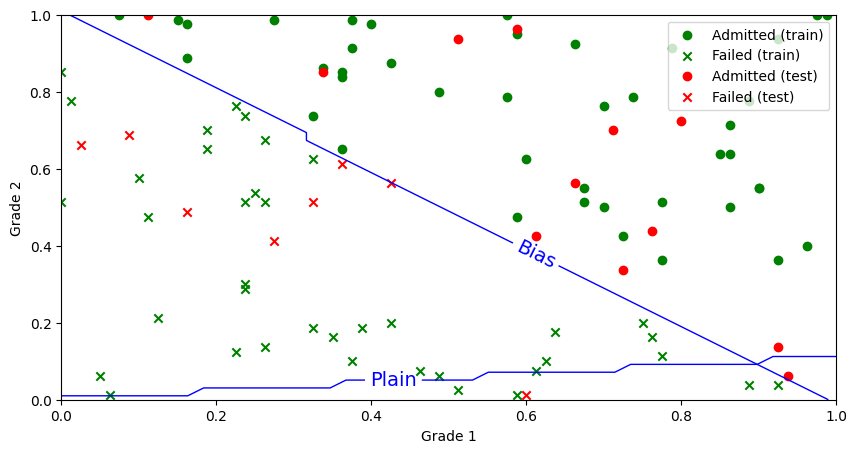

In [21]:
    
Xgrades_train = Xgrades_norm[:80, :]
Xgrades_test  = Xgrades_norm[80:, :]
Ygrades_train = Ygrades[:80   ]
Ygrades_test  = Ygrades[80:   ]

yes_train = Ygrades_train == 1
yes_test  = Ygrades_test  == 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(Xgrades_train[yes_train, 0], 
           Xgrades_train[yes_train, 1], 
           color='green', marker='o', label='Admitted (train)')
ax.scatter(Xgrades_train[~yes_train, 0], 
           Xgrades_train[~yes_train, 1], 
           color='green', marker='x', label='Failed (train)')
ax.scatter(Xgrades_test[yes_test, 0], 
           Xgrades_test[yes_test, 1], 
           color='red', marker='o', label='Admitted (test)')
ax.scatter(Xgrades_test[~yes_test, 0], 
           Xgrades_test[~yes_test, 1], 
           color='red', marker='x', label='Failed (test)')



# Create grades space: btween 0 and 1 (normalized) with a resolution of 50
xrange = np.linspace(0, 1, 50) # Grade 1
yrange = np.linspace(0, 1, 50) # Grade 2

# Dessiner la ligne de séparation dans une régression linéaire
LR_plain = LogisticRegression(penalty=None, fit_intercept=False)
LR_plain.fit(Xgrades_train, Ygrades_train)
draw2D(LR_plain, ax, xrange, yrange, label='Plain', color='blue')

LR_bias = LogisticRegression(penalty=None)
LR_bias.fit(Xgrades_train, Ygrades_train)
draw2D(LR_bias, ax, xrange, yrange, label='Bias', color='blue')



plt.xlabel('Grade 1')
plt.ylabel('Grade 2')
plt.legend(loc='upper right')
plt.show()

**TODO: Analyze the results**

1. Why the hyperplane (Plain) crosses 0.0?
2. Is there a case of underfitting or overfitting? Explain.

**Answers**
1. The hyperplane passes through the origin (0,0) because it is mathematically constructed to do so, given that the bias term is 0. The equation of the model is θ₁x₁ + θ₂x₂ = 0. If one of the two feature values is equal to 0, the other must also be 0 to satisfy the equation. Therefore, the hyperplane crosses the origin.

2. The Plain hyperplane exhibits underfitting because setting the bias term to zero restricts the model’s flexibility. By nullifying the bias, we force the decision boundary to pass through the origin. However, the true decision boundary in this case is at 10 (or 0.5 if normalized), not at 0. Because of this constraint, the model cannot properly align with the real separation between classes. As a result, it misclassifies many training examples, leading to a higher classification error.

#### II.1.2. Normalization

We want to test if normalizing data affects model training. 
To this end, we want to test two aspects:
1. Convergence speed
1. Convergence quality

This is why we trained two models: One on the original data and another on the normalized data. Then, we plotted the cost history according to the iterations.

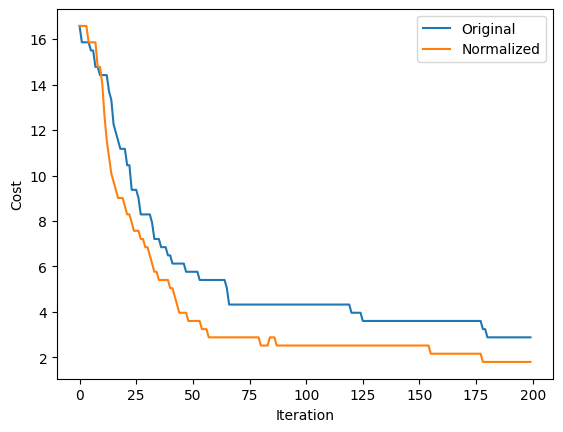

In [22]:
# We will use SGDClassifier instead of LogisticRegression
# Because LogisticRegression does not permit learning rate definition
# we will use "partial_fit" instead of "fit" which is a mini-batch implementation
# but, we pass all the dataset

ALPHA = 0.01
ITMAX = 200

LRbin_orig = SGDClassifier(penalty=None, 
                           warm_start=True, 
                           loss='log_loss', 
                           learning_rate='constant', 
                           eta0=ALPHA,
                           shuffle=False
                          )
LRbin_norm = SGDClassifier(penalty=None, 
                           warm_start=True, 
                           loss='log_loss', 
                           learning_rate='constant', 
                           eta0=ALPHA,
                           shuffle=False
                          )

classes = np.unique(Ygrades)
costs_orig = []
costs_norm = []

for it in range(ITMAX):
    LRbin_orig.partial_fit(Xgrades,      Ygrades, classes=classes)
    LRbin_norm.partial_fit(Xgrades_norm, Ygrades, classes=classes)
    
    costs_orig.append(log_loss(Ygrades, LRbin_orig.predict(Xgrades     )))
    costs_norm.append(log_loss(Ygrades, LRbin_norm.predict(Xgrades_norm)))

# Visualization
plt.plot(costs_orig, label = 'Original')
plt.plot(costs_norm  , label = 'Normalized')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
#plt.autoscale()
plt.show()

**TODO: Analyze the results**

We note that normalized-data-based model converge faster and better than the original-data-based one in term of iterations. Faster = it reaches its optimal point where it cannot enhance the error more quickly. Better: the error when it converges is less.

1. Explain how normalization can speed up convergence in terms of iterations' number.
1. Explain how normalization can enhance convergence quality in terms of classification error.

**Answers**
1. When features have vastly different scales (e.g., some in [0, 100] and others in [0, 1]), the gradients computed with respect to each parameter can have very different magnitudes, causing some parameters to converge much more slowly than others. Normalizing the data helps the model converge faster because it places all features on a similar scale, making gradient descent more stable and efficient. When feature ranges differ significantly, the cost function becomes poorly conditioned , which causes the algorithm to take many small steps toward the minimum. By normalizing the data, the cost surface becomes better shaped, gradients are more balanced resulting in fewer iterations required for convergence.

2. Normalization enhances convergence quality (lower final error) because it ensures all parameters are optimized at similar rates. Without normalization, features with large original scales dominate the learning process, while features with small scales learn much slower. This imbalance causes some parameters to converge to suboptimal values while waiting for slower parameters to catch up. When data is normalized, all parameters have equal learning opportunities, allowing the algorithm to fine-tune all parameters simultaneously and find a better overall solution. This balanced optimization leads to a lower final classification error and better generalization.

#### II.1.3. Learning rate

We want to test the effect of learning rate on training convergence. This is why we trained identical models with different learning rates and then plotted the cost history for each.

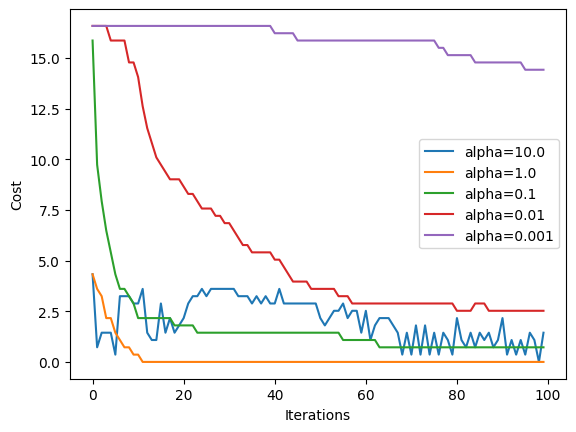

In [23]:
ITMAX  = 100
alphas = [10.,1., 0.1, 0.01, 0.001]

classes = np.unique(Ygrades)

# For each training rate, we train a separate model
for alpha in alphas:
    # Create a new logistic regression model
    mdl = SGDClassifier(penalty=None, 
                        warm_start=True, 
                        loss='log_loss', 
                        learning_rate='constant', 
                        eta0=alpha,
                        shuffle=False
                        )
    costs = []
    for it in range(ITMAX):
        # train the model
        mdl.partial_fit(Xgrades_norm, Ygrades, classes=classes)
        costs.append(log_loss(Ygrades, mdl.predict(Xgrades_norm)))
        
    # Visualization
    plt.plot(costs, label = 'alpha=' + str(alpha))
    
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()
#plt.autoscale()
plt.show()

**TODO: Analyze the results**

We note that the model converges fast when alpha=0.1. In fact, it converges around iteration 15. When alpha is smaller, the model takes more iterations to converge. For example, the model with alpha=1.0 didn't converge even after 100 iterations.

**Hypothesis:** a larger learning rate can lead to faster convergence 

1. Justify this hypothesis.
2. If we use just one update using a learning rate of 1 what will happen?
3. If we execute many iterations using a large learning rate what will happen?

**Answer**
1. A larger learning rate means bigger steps toward the minimum of the cost function. If α is well chosen (not too large, not too small), the algorithm can reach the minimum in fewer iterations, which explains why α = 1.0 converges faster than smaller values. However, the learning rate must remain within a stable range. If it becomes too large, the updates may overshoot the minimum instead of approaching it smoothly ( example , alpha=10)

2. If we use just one update with a large learning rate such as α = 1, the model will take a very large step in the direction of the negative gradient. While the gradient indicates the correct direction toward the minimum, an excessively large step can overshoot the optimal point and move the parameters far beyond it. Instead of reducing the cost, this may increase it, pushing the model away from the minimum rather than closer to it .

3. If the learning rate is too large and we run many iterations:
- The algorithm may oscillate around the minimum.
- It may repeatedly overshoot.
- It may even diverge (the cost keeps increasing)

### II.2. Multi-class Logistic Regression 

We want to compare some methods for Multi-class Logistic Regression:
- Maximum entropy (MaxEnt)
- One-vs-Rest  (OvR)
- One-vs-One  (OvO)

In [24]:
# https://goshippo.com/blog/measure-real-size-any-python-object/
# This function will be used to get the size of a trained model
def get_size(obj, seen=None):
    """Recursively finds size of objects"""
    size = sys.getsizeof(obj)
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return 0
    # Important mark as seen *before* entering recursion to gracefully handle
    # self-referential objects
    seen.add(obj_id)
    if isinstance(obj, dict):
        size += sum([get_size(v, seen) for v in obj.values()])
        size += sum([get_size(k, seen) for k in obj.keys()])
    elif hasattr(obj, '__dict__'):
        size += get_size(obj.__dict__, seen)
    elif hasattr(obj, '__iter__') and not isinstance(obj, (str, bytes, bytearray)):
        size += sum([get_size(i, seen) for i in obj])
    return size

get_size({'first': 0.21, 'second': 'string'})

348

In [25]:
# A function to facilitate testing multiple models
# it depends on global variables: Xbody_train, Ybody_train, Xbody_test, Ybody_test
def multi_eval(mdls, X_trn=Xbody_train, Y_trn=Ybody_train, X_tst=Xbody_test, Y_tst=Ybody_test): 
    # performance metrics
    perf = {
        'trn_time': [],
        'tst_time': [],
        'trn_acc' : [],
        'tst_acc' : [],
        'size'    : [],
    }
    
    for mdl in mdls:
        start_time = timeit.default_timer()
        mdl.fit(X_trn, Y_trn)
        perf['trn_time'].append(timeit.default_timer() - start_time)
    
        Y_pred = mdl.predict(X_trn)
        perf['trn_acc'].append(accuracy_score(Y_trn, Y_pred))
    
        start_time = timeit.default_timer()
        Y_pred = mdl.predict(X_tst)
        perf['tst_time'].append(timeit.default_timer() - start_time)
        perf['tst_acc'].append(accuracy_score(Y_tst, Y_pred))
        
        perf['size'].append(get_size(mdl))
        
    return perf
    
print('DONE')

DONE


#### II.2.1. OvR vs. MaxEnt

We want to compare OvR and MaxEnt based on accuracy. We know that the models are almost identical in term of parameters size. The difference:

| Model   |      OvR      |  MaxEnt |
| :--- |:---|:---|
| Activation function |  Logistic | Softmax |
| Cost function |  Binary cross entropy   | Cross entropy |
| Estimation | Maximal probability | Maximal probability |

In [26]:
# n_jobs: use just one CPU core
# this one will be deprcated in future versions; it is faster than the next one
# ovr     = LogisticRegression(n_jobs=1, max_iter=200, solver='lbfgs', penalty=None, multi_class='ovr'        )
# this one takes more size qnd time
ovr2    = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=200, penalty=None, n_jobs=1), n_jobs=1)
maxent  = LogisticRegression(n_jobs=1, max_iter=200, solver='lbfgs', penalty=None)
# ovrP     = LogisticRegression(n_jobs=2, max_iter=200, solver='lbfgs', penalty=None, multi_class='ovr'        )
# maxentP  = LogisticRegression(n_jobs=2, max_iter=200, solver='lbfgs', penalty=None, multi_class='multinomial')

perf = multi_eval([ovr2, maxent]) # [ovr, maxent, ovrP, maxentP]

pd.DataFrame({
    'Algorithm'     : ['OvR', 'MaxEnt'], # ['OvR', 'MaxEnt', 'OvRP', 'MaxEntP']
    'Size'          : perf['size'     ],
    'Train time'    : perf['trn_time' ],
    'Test time'     : perf['tst_time' ],
    'Train Accuracy': perf['trn_acc'  ],
    'Test Accuracy' : perf['tst_acc'  ],
})

/home/bila/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bila/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/bila/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l

,Algorithm,Size,Train time,Test time,Train Accuracy,Test Accuracy
0,OvR,7749,0.223798,0.000744,0.593709,0.597984
1,MaxEnt,3237,0.174102,0.000882,0.620123,0.624860


**TODO: Analyze the results**

We note that the size, train time, test time are almost the same. 

As for the accuracy (train and test), MaXent has better quality than OvR.

1. Why (based on the boundary decision hyperplane/decision mechanism)?
2. Why (based on parameters update manner)?

**Answer**

1. **Decision boundaries (hyperplane mechanism):** OvR trains K independent binary classifiers, each creating a decision boundary that separates one class from all others. These boundaries are learned independently without considering how they interact globally. This can lead to ambiguous or overlapping regions where multiple classifiers output high probabilities simultaneously, or contradictory regions where no classifier is confident. MaxEnt (softmax), on the other hand, jointly learns the decision boundaries for all classes simultaneously. The softmax activation function ensures that class probabilities sum to 1 and are probabilistically interdependent , when one class probability increases, others must decrease. This constraint creates more consistent and decision boundaries that don't have ambiguous regions.

2. **Parameters update manner:** In OvR, each binary classifier updates its parameters independently using its own Binary Cross Entropy (BCE) loss function. The gradients computed for one classifier have no direct influence on the others, meaning there is no global coordination during training. Each classifier optimizes its own objective without considering the overall multi-class prediction quality. In MaxEnt, all parameters are updated simultaneously based on a single Cross Entropy (CE) loss function computed over all classes. The softmax function creates dependencies: updating parameters to increase one class probability automatically affects other class probabilities (through the normalization constraint). This joint optimization with shared loss allows the model to find better solutions by considering tradeoffs between all classes at once, leading to better calibrated probabilities and lower overall training error.

#### II.2.3. OvR vs. OvO

We want to compare OvR and OvO using logistic regression. 
We duplicated the data so we will have many samples.


In [27]:
REP = 100

Xbody_trainM = np.repeat(Xbody_train, REP, axis=0)
Ybody_trainM = np.repeat(Ybody_train, REP, axis=0)
Xbody_testM = np.repeat(Xbody_test, REP, axis=0)
Ybody_testM = np.repeat(Ybody_test, REP, axis=0)

ovr_seq = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=100, penalty=None, n_jobs=1), n_jobs=1)
ovo_seq = OneVsOneClassifier (LogisticRegression(solver='lbfgs', max_iter=100, penalty=None, n_jobs=1), n_jobs=1)
ovr_con = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=100, penalty=None, n_jobs=1), n_jobs=-1)
ovo_con = OneVsOneClassifier (LogisticRegression(solver='lbfgs', max_iter=100, penalty=None, n_jobs=1), n_jobs=-1)


perf = multi_eval([ovr_seq, ovo_seq, ovr_con, ovo_con], 
                  X_trn=Xbody_trainM, 
                  Y_trn=Ybody_trainM, 
                  X_tst=Xbody_testM, 
                  Y_tst=Ybody_testM)
# multi_eval(mdls, X_trn=Xbody_trainM, Y_trn=Ybody_trainM, X_tst=Xbody_testM, Y_tst=Ybody_testM)

pd.DataFrame({
    'Algorithm'     : ['Sequential OvR', 'Sequential OvO', 'Concurrent OvR', 'Concurrent OvO'],
    'Size'          : perf['size'     ],
    'Train time'    : perf['trn_time' ],
    'Test time'     : perf['tst_time' ],
    'Train Accuracy': perf['trn_acc'  ],
    'Test Accuracy' : perf['tst_acc'  ],
})

/home/bila/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bila/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/bila/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l

,Algorithm,Size,Train time,Test time,Train Accuracy,Test Accuracy
0,Sequential OvR,6725,10.397135,0.031175,0.593709,0.597984
1,Sequential OvO,7941,9.761691,0.164208,0.623390,0.627473
2,Concurrent OvR,7145,5.971400,0.110984,0.593709,0.597984
3,Concurrent OvO,8557,10.527571,0.221058,0.623390,0.627473


**TODO: Analyze the results**

1. Why the size of OvO is greater than OvR's?
2. Why OvO takes less time to train than OvR?
3. Why OvO takes more time to test than OvR?
4. Why OvO generalizes better than OvR?
5. How to modify OvR for multi-label classification? 
6. How to modify OvO for multi-label classification?

**Answer**

1. **Model size:** OvR creates K binary classifiers (one for each class). OvO creates K(K-1)/2 binary classifiers (one for each pair of classes). Since OvO trains more classifiers and each stores parameters, the total model size is significantly larger.

2. **Training time:** OvO trains faster than OvR despite having more classifiers because each OvO binary classifier trains on a much smaller dataset , only the samples from the two classes it distinguishes. In contrast, OvR trains each classifier on the entire dataset. Even though OvO has more classifiers, each one converges faster due to the reduced training set size. 

3. **Test time:** OvO takes more time during prediction because it must run K(K-1)/2 classifiers and aggregate their results to make one final prediction. OvR only needs to run K classifiers and select the one with the highest probability. 

4. **Generalization:** OvO generalizes better because each binary classifier solves a simpler, more balanced problem. Each OvO classifier only distinguishes between two classes, avoiding the "one-vs-many" imbalance in OvR. OvR classifiers must separate one class from all others combined, which is harder when the "all others" class is diverse and imbalanced. The simpler binary problems in OvO lead to better decision boundaries, fewer classification conflicts, and better generalization to test data.

5. **OvR for multi-label:** To adapt OvR for multi-label classification, train K independent binary classifiers (one for each label). Each classifier solves a binary problem: "Is this label present or not?" For each test sample, run all K classifiers independently and output a binary vector indicating which labels are predicted. This naturally extends to multi-label because multiple labels can be active simultaneously.

6. **OvO for multi-label:** OvO is inherently designed for mutually exclusive multi-class problems, so direct adaptation for multi-label is not natural. However, we could convert the multi-label problem into multiple multi-class problems, but this becomes complex. The simplest approach is to use the OvR-like strategy of K independent binary classifiers rather than true OvO.

In [28]:
'END OF LAB ...'

'END OF LAB ...'